In [2]:
import tensorflow as tf
import numpy as np
from sklearn import metrics
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
from keras.datasets import imdb

In [4]:
(x_train, y_train), (x_test, y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
x_train[0]
len(x_train[0])

218

In [8]:
from keras.utils import pad_sequences

x_train = pad_sequences(x_train, maxlen=50, padding="post")
x_test = pad_sequences(x_test, maxlen=50, padding="post")

In [9]:
!pip install tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import SimpleRNN, Dropout, Dense, BatchNormalization

In [10]:
from tensorflow.keras.layers import LSTM

In [11]:
model = Sequential()
model.add(LSTM(1024, return_sequences=True, input_shape=(50, 1)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(512, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(256, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 1024)       │     4,202,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 512)        │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 256)        │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             

 Total params: 8,456,449 (32.26 MB)

 Trainable params: 8,452,417 (32.24 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [13]:
from tensorflow.keras.optimizers import Adam
model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate = 1e-3), metrics=["accuracy"])

In [14]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.5161 - loss: 0.6950 - val_accuracy: 0.5274 - val_loss: 0.6912
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.5156 - loss: 0.6929 - val_accuracy: 0.4940 - val_loss: 0.6956
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.5145 - loss: 0.6929 - val_accuracy: 0.4872 - val_loss: 0.6935
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.5257 - loss: 0.6916 - val_accuracy: 0.5136 - val_loss: 0.6927
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.5095 - loss: 0.6929 - val_accuracy: 0.4936 - val_loss: 0.6956
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.5175 - loss: 0.6923 - val_accuracy: 0.5074 - val_loss: 0.6937
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.5252 - loss: 0.6920 - val_accuracy: 0.5076 - val_loss: 0.6927
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.5082 - loss: 0.6932 - 

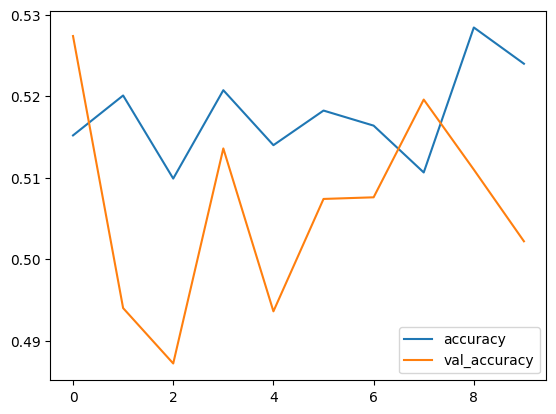

In [15]:
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.show()

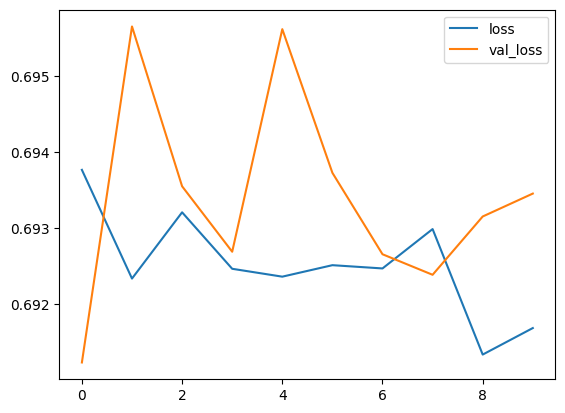

In [16]:
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend()
plt.show()

Improve Model HW

In [17]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, BatchNormalization
from keras.regularizers import l2

In [18]:
model1 = Sequential()
model1.add(LSTM(512, return_sequences=True, input_shape=(50, 1), kernel_regularizer=l2(0.01)))  # Regularization added
model1.add(BatchNormalization())
model1.add(Dropout(0.3))  # Increased dropout
model1.add(LSTM(256, return_sequences=True, kernel_regularizer=l2(0.01)))  # Regularization added
model1.add(BatchNormalization())
model1.add(Dropout(0.3))  # Increased dropout
model1.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.01)))  # Regularization added
model1.add(BatchNormalization())
model1.add(Dropout(0.3))  # Increased dropout
model1.add(Dense(128, activation="relu", kernel_regularizer=l2(0.01)))  # Regularization added
model1.add(Dropout(0.3))  # Increased dropout
model1.add(Dense(64, activation="relu", kernel_regularizer=l2(0.01)))  # Regularization added
model1.add(Dropout(0.3))  # Increased dropout
model1.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50, 512)        │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50, 256)        │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,065,665 (7.88 MB)

 Trainable params: 2,063,873 (7.87 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [20]:
model1.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate = 1e-3), metrics=["accuracy"])

In [21]:
history1 = model1.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.5178 - loss: 5.7368 - val_accuracy: 0.5246 - val_loss: 0.7686
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.5273 - loss: 0.7311 - val_accuracy: 0.5244 - val_loss: 0.6965
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.5197 - loss: 0.6969 - val_accuracy: 0.5078 - val_loss: 0.6957
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.5204 - loss: 0.6961 - val_accuracy: 0.4994 - val_loss: 0.6958
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.5138 - loss: 0.6957 - val_accuracy: 0.4952 - val_loss: 0.7321
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.4968 - loss: 0.7010 - val_accuracy: 0.5062 - val_loss: 0.6950
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.5059 - loss: 0.6964 - val_accuracy: 0.5062 - val_loss: 0.7015
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.4975 - loss: 0.6956 - 

In [22]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, BatchNormalization, Embedding
from keras.regularizers import l2

model2 = Sequential()
model2.add(Embedding(10000, 128))  # Assuming a vocabulary size of 10000
model2.add(LSTM(256, return_sequences=True, input_shape=(100, 1), kernel_regularizer=l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation="relu", kernel_regularizer=l2(0.001)))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model2.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=1e-4), metrics=["accuracy"])

In [25]:
history2 = model2.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.5231 - loss: 1.5900 - val_accuracy: 0.6480 - val_loss: 1.3097
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6716 - loss: 1.2723 - val_accuracy: 0.7398 - val_loss: 1.1031
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8034 - loss: 1.0184 - val_accuracy: 0.7072 - val_loss: 1.1569
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8547 - loss: 0.8666 - val_accuracy: 0.7722 - val_loss: 1.0233
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.8839 - loss: 0.7534 - val_accuracy: 0.7582 - val_loss: 1.0156
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8986 - loss: 0.6689 - val_accuracy: 0.7774 - val_loss: 0.9379
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9135 - loss: 0.5962 - val_accuracy: 0.7506 - val_loss: 1.1411
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9290 - loss: 0.5298 - 

In [1]:
plt.plot(history2.history["accuracy"], label = "accuracy")
plt.plot(history2.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.show()

NameError: name 'plt' is not defined